In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.interpolate import interp1d, UnivariateSpline

# generate dataset
X, y = make_regression(
    n_samples=50000,
    n_features=20,
    noise=10,
    random_state=42
)

# split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4)

X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_cal_pred = model.predict(X_cal)
y_test_pred = model.predict(X_test)

# cal Nonconformity Scores score = |y - yhat|
cal_scores = np.abs(y_cal - y_cal_pred)

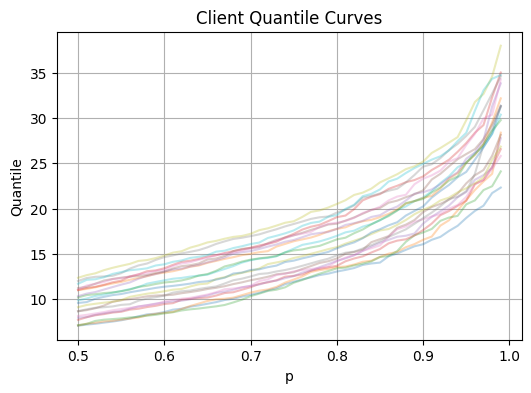

Centralized threshold: 16.44312703754614
Iterative baseline: 20.983380678995488
Iterative error: 4.540253641449347
QoQ (Homogeneous): 16.386889343178037
QoQ (Heterogeneous): 20.625587221568168

Errors vs Centralized:
QoQ Homo Error: 0.056237694368103774
QoQ Hetero Error: 4.182460184022027


In [48]:
# client splits
def split_clients_homo(scores, num_clients):
    return np.array_split(scores, num_clients)

def split_clients_hetero(scores, num_clients):
    split = np.array_split(scores, num_clients)
    hetero_clients = []

    for i, s in enumerate(split):
        scale = 1 + 0.3 * (i / num_clients)
        shift = 0.2 * i
        new_scores = s * scale + shift
        hetero_clients.append(new_scores)

    return hetero_clients

num_clients = 20

client_scores_homo = split_clients_homo(cal_scores, num_clients)
client_scores_hetero = split_clients_hetero(cal_scores, num_clients)

def plot_client_quantile_curves(client_scores, num_points=50):
    ps = np.linspace(0.5, 0.99, num_points)
    plt.figure(figsize=(6,4))
    for scores in client_scores:
        qs = np.quantile(scores, ps)
        plt.plot(ps, qs, alpha=0.3)
    plt.title("Client Quantile Curves")
    plt.xlabel("p")
    plt.ylabel("Quantile")
    plt.grid()
    plt.show()

# visualize heterogeneity
plot_client_quantile_curves(client_scores_hetero)

# centralized baseline
alpha = 0.1

def centralized_quantile(scores, alpha):
    return np.quantile(scores, 1 - alpha)

q_central = centralized_quantile(cal_scores, alpha)
print("Centralized threshold:", q_central)

# QoQ baseline
def quantile_of_quantiles(client_scores, alpha):
    local_q = []
    for scores in client_scores:
        q = np.quantile(scores, 1 - alpha)
        local_q.append(q)
    return np.mean(local_q)

# compute separately for homo & hetero
q_qoq_homo = quantile_of_quantiles(client_scores_homo, alpha)
q_qoq_hetero = quantile_of_quantiles(client_scores_hetero, alpha)

# quantile error
def quantile_error(q_est, q_true):
    return abs(q_est - q_true)

# iterative baseline
def iterative_quantile_sync(client_scores, alpha, rounds=10):
    low, high = 0, max(np.max(s) for s in client_scores)

    for _ in range(rounds):
        mid = (low + high) / 2
        cdfs = [(scores <= mid).mean() for scores in client_scores]
        global_cdf = np.mean(cdfs)

        if global_cdf < 1 - alpha:
            low = mid
        else:
            high = mid

    return (low + high) / 2

q_iter_hetero = iterative_quantile_sync(client_scores_hetero, alpha, rounds=10)
print("Iterative baseline:", q_iter_hetero)
print("Iterative error:", quantile_error(q_iter_hetero, q_central))

print("QoQ (Homogeneous):", q_qoq_homo)
print("QoQ (Heterogeneous):", q_qoq_hetero)

# coverage + width
def compute_coverage(y_true, y_pred, threshold):
    lower = y_pred - threshold
    upper = y_pred + threshold
    return np.mean((y_true >= lower) & (y_true <= upper))

def prediction_width(threshold):
    return 2 * threshold

print("\nErrors vs Centralized:")
print("QoQ Homo Error:", quantile_error(q_qoq_homo, q_central))
print("QoQ Hetero Error:", quantile_error(q_qoq_hetero, q_central))


In [49]:
# sparse multi-quantile
def sparse_multi_quantile(client_scores, probs):
    client_quantiles = []
    weights = []

    for scores in client_scores:
        q = np.quantile(scores, probs)
        client_quantiles.append(q)
        weights.append(len(scores))

    client_quantiles = np.array(client_quantiles)
    weights = np.array(weights)
    weights = weights / weights.sum()

    # weighted average across clients
    global_quantiles = np.average(client_quantiles, axis=0, weights=weights)

    return np.array(probs), np.array(global_quantiles)


# interpolation baseline
def estimate_global_threshold(probs, quantiles, alpha):
    target = 1 - alpha

    # ensure sorted
    idx = np.argsort(probs)
    probs = probs[idx]
    quantiles = quantiles[idx]

    return float(np.interp(target, probs, quantiles))


# interpolation new method
def estimate_threshold_interp(p, q, alpha, method="linear"):
    target = 1 - alpha

    if method == "linear":
        f = interp1d(p, q, kind='linear', fill_value="extrapolate")
    elif method == "cubic":
        f = interp1d(p, q, kind='cubic', fill_value="extrapolate")
    elif method == "spline":
        f = UnivariateSpline(p, q, s=0)

    return float(f(target))

# α-Adaptive grid
def alpha_adaptive_tail_grid(alpha, k, delta_low=0.05, delta_high=0.02):
    center = 1 - alpha
    low = center - delta_low * alpha
    high = center + delta_high * alpha
    return np.linspace(low, high, k)

k = 5
probs = alpha_adaptive_tail_grid(alpha, k)

# homogeneous
p_h, q_h = sparse_multi_quantile(client_scores_homo, probs)
q_sparse_homo = estimate_global_threshold(p_h, q_h, alpha)

# heterogeneous
p_he, q_he = sparse_multi_quantile(client_scores_hetero, probs)
q_sparse_hetero = estimate_global_threshold(p_he, q_he, alpha)


coverage = compute_coverage(y_test, y_test_pred, q_sparse_hetero)
width = prediction_width(q_sparse_hetero)

print("Coverage:", coverage)
print("Width:", width)

print("Sparse (Homo):", q_sparse_homo)
print("Sparse (Hetero):", q_sparse_hetero)


# communication cost
def communication_cost(num_clients, k):
    return num_clients * k * 32  # bits

def iterative_comm_cost(num_clients, rounds):
    return num_clients * rounds * 32  # 1 scalar per round


# error comparison
print("\nErrors vs Centralized:")
print("QoQ Homo Error:", quantile_error(q_qoq_homo, q_central))
print("QoQ Hetero Error:", quantile_error(q_qoq_hetero, q_central))

print("Sparse Homo Error:", quantile_error(q_sparse_homo, q_central))
print("Sparse Hetero Error:", quantile_error(q_sparse_hetero, q_central))


Coverage: 0.9596
Width: 41.257300612127665
Sparse (Homo): 16.38957328860844
Sparse (Hetero): 20.628650306063832

Errors vs Centralized:
QoQ Homo Error: 0.056237694368103774
QoQ Hetero Error: 4.182460184022027
Sparse Homo Error: 0.05355374893770204
Sparse Hetero Error: 4.1855232685176915


Iterative baseline: 18.55910619140796
Iterative error: 2.1159791538618187
linear error: 1.9244154849774837
cubic error: 1.9243870131097403
spline error: 1.9243870131097438


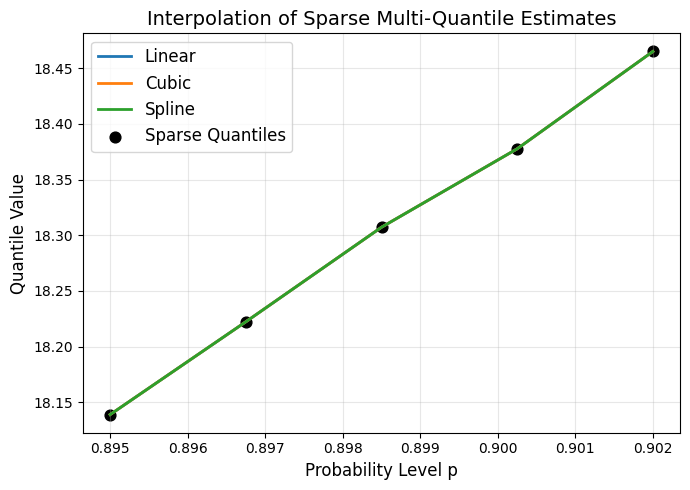

In [44]:
# settings
ks = [2, 3, 4, 5, 6]

errors_homo = []
errors_hetero = []
errors_uniform = []
errors_tail = []

# experiment
for k in ks:
    probs_uniform = np.linspace(0.5, 0.95, k)
    probs_tail = alpha_adaptive_tail_grid(alpha, k)

    # homogeneous (tail-aware)
    p, q = sparse_multi_quantile(client_scores_homo, probs_tail)
    q_est = estimate_global_threshold(p, q, alpha)
    errors_homo.append(quantile_error(q_est, q_central))

    # heterogeneous (tail-aware)
    p, q = sparse_multi_quantile(client_scores_hetero, probs_tail)
    q_est_tail = estimate_global_threshold(p, q, alpha)
    errors_tail.append(quantile_error(q_est_tail, q_central))

    # heterogeneous (uniform)
    p, q = sparse_multi_quantile(client_scores_hetero, probs_uniform)
    q_est_uniform = estimate_global_threshold(p, q, alpha)
    errors_uniform.append(quantile_error(q_est_uniform, q_central))

# QoQ baseline
qoq_error_homo = quantile_error(q_qoq_homo, q_central)
qoq_error_hetero = quantile_error(q_qoq_hetero, q_central)

# iterative baseline (make sure iterative_quantile_sync is defined earlier)
q_iter_hetero = iterative_quantile_sync(client_scores_hetero, alpha, rounds=10)
print("Iterative baseline:", q_iter_hetero)
print("Iterative error:", quantile_error(q_iter_hetero, q_central))

# Calculate iter_errors for various rounds
rounds_list = [1, 2, 5, 10, 20]
iter_errors = []
for r in rounds_list:
    q_iter = iterative_quantile_sync(client_scores_hetero, alpha, rounds=r)
    iter_errors.append(quantile_error(q_iter, q_central))

# vary number of clients
client_list = [5, 10, 20, 50]
client_errors = []

for n in client_list:
    clients = split_clients_hetero(cal_scores, n)
    probs_tail = alpha_adaptive_tail_grid(alpha, k=5)
    p, q = sparse_multi_quantile(clients, probs_tail)
    q_est = estimate_global_threshold(p, q, alpha)
    client_errors.append(quantile_error(q_est, q_central))

# interpolation comparison
methods = ["linear", "cubic", "spline"]
probs_tail = alpha_adaptive_tail_grid(alpha, k=5)
p, q = sparse_multi_quantile(client_scores_hetero, probs_tail)

for m in methods:
    q_est = estimate_threshold_interp(p, q, alpha, method=m)
    print(m, "error:", quantile_error(q_est, q_central))

# interpolation Curve Plot
plt.figure(figsize=(7,5))

# Sort p and q for plotting
idx = np.argsort(p)
p_sorted = p[idx]
q_sorted = q[idx]

# Linear interpolation curve
f_lin = interp1d(p_sorted, q_sorted, kind='linear', fill_value="extrapolate")
plt.plot(p_sorted, f_lin(p_sorted), label="Linear", linewidth=2)

# Cubic interpolation curve
f_cub = interp1d(p_sorted, q_sorted, kind='cubic', fill_value="extrapolate")
plt.plot(p_sorted, f_cub(p_sorted), label="Cubic", linewidth=2)

# Spline interpolation curve
f_spl = UnivariateSpline(p_sorted, q_sorted, s=0)
plt.plot(p_sorted, f_spl(p_sorted), label="Spline", linewidth=2)

# Original sparse points
plt.scatter(p_sorted, q_sorted, color='black', s=60, label="Sparse Quantiles")

plt.xlabel("Probability Level p", fontsize=12)
plt.ylabel("Quantile Value", fontsize=12)
plt.title("Interpolation of Sparse Multi-Quantile Estimates", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

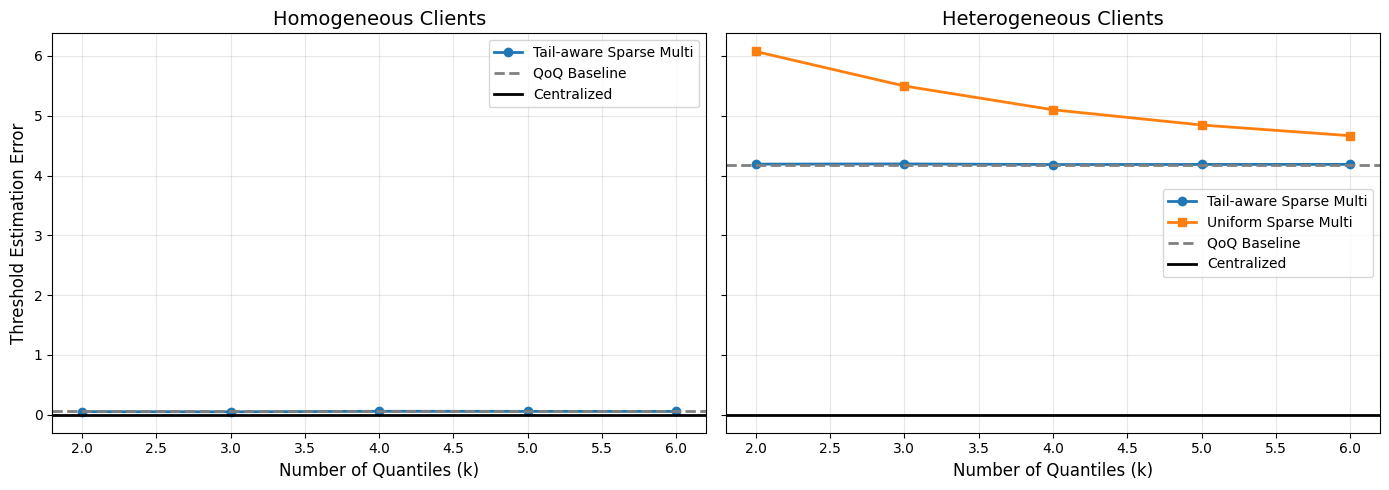

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
# homogeneous
ax = axes[0]
ax.plot(ks, errors_homo, marker='o', linewidth=2, label="Tail-aware Sparse Multi")
ax.axhline(y=qoq_error_homo, linestyle='--', color='gray', linewidth=2, label="QoQ Baseline")
ax.axhline(y=0, linestyle='-', color='black', linewidth=2, label="Centralized")
ax.set_title("Homogeneous Clients", fontsize=14)
ax.set_xlabel("Number of Quantiles (k)", fontsize=12)
ax.set_ylabel("Threshold Estimation Error", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

# heterogeneous
ax = axes[1]
ax.plot(ks, errors_tail, marker='o', linewidth=2, label="Tail-aware Sparse Multi")
ax.plot(ks, errors_uniform, marker='s', linewidth=2, label="Uniform Sparse Multi")
ax.axhline(y=qoq_error_hetero, linestyle='--', color='gray', linewidth=2, label="QoQ Baseline")
ax.axhline(y=0, linestyle='-', color='black', linewidth=2, label="Centralized")
ax.set_title("Heterogeneous Clients", fontsize=14)
ax.set_xlabel("Number of Quantiles (k)", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


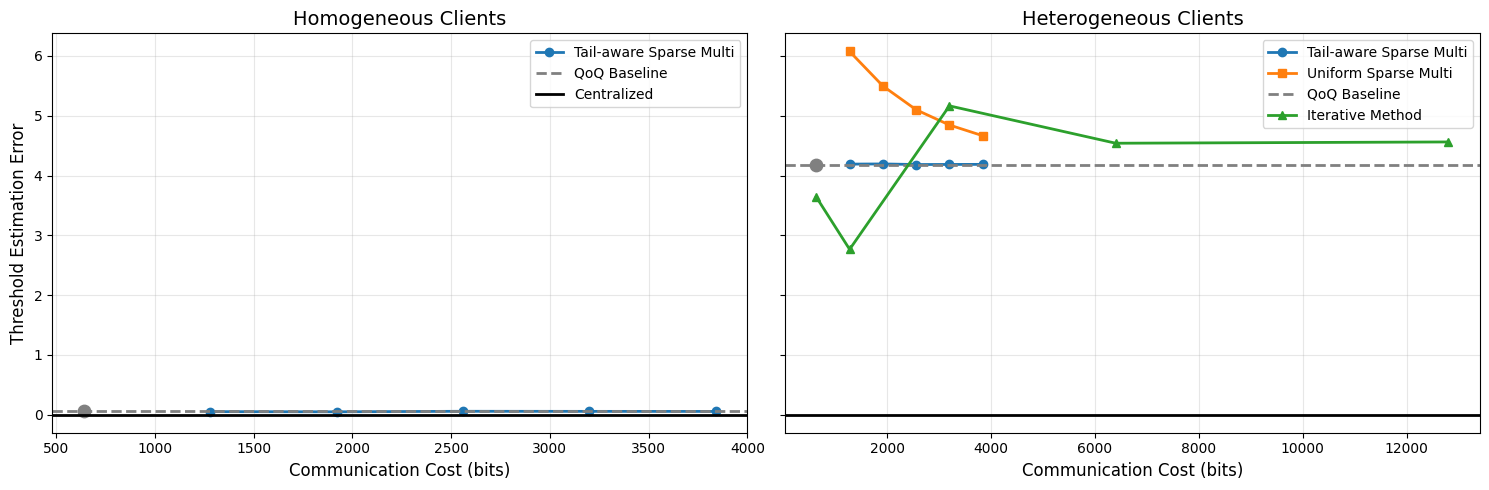

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

# Homogeneous Clients
ax = axes[0]

# Communication cost for sparse multi
costs_sparse = [communication_cost(num_clients, k) for k in ks]

# Communication cost for iterative
costs_iter = [iterative_comm_cost(num_clients, r) for r in rounds_list]

# Tail-aware sparse multi
ax.plot(costs_sparse, errors_homo, marker='o', linewidth=2, label="Tail-aware Sparse Multi")

# QoQ baseline
qoq_cost = communication_cost(num_clients, 1)
ax.axhline(y=qoq_error_homo, linestyle='--', color='gray', linewidth=2, label="QoQ Baseline")
ax.scatter([qoq_cost], [qoq_error_homo], color='gray', s=80)

# Centralized
ax.axhline(y=0, linestyle='-', color='black', linewidth=2, label="Centralized")

ax.set_title("Homogeneous Clients", fontsize=14)
ax.set_xlabel("Communication Cost (bits)", fontsize=12)
ax.set_ylabel("Threshold Estimation Error", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)


# Panel 2: Heterogeneous Clients
ax = axes[1]

# Tail-aware sparse multi
ax.plot(costs_sparse, errors_tail, marker='o', linewidth=2, label="Tail-aware Sparse Multi")

# Uniform sparse multi
ax.plot(costs_sparse, errors_uniform, marker='s', linewidth=2, label="Uniform Sparse Multi")

# QoQ baseline
ax.axhline(y=qoq_error_hetero, linestyle='--', color='gray', linewidth=2, label="QoQ Baseline")
ax.scatter([qoq_cost], [qoq_error_hetero], color='gray', s=80)

# Iterative method
ax.plot(costs_iter, iter_errors, marker='^', linewidth=2, label="Iterative Method")

# Centralized
ax.axhline(y=0, linestyle='-', color='black', linewidth=2)

ax.set_title("Heterogeneous Clients", fontsize=14)
ax.set_xlabel("Communication Cost (bits)", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


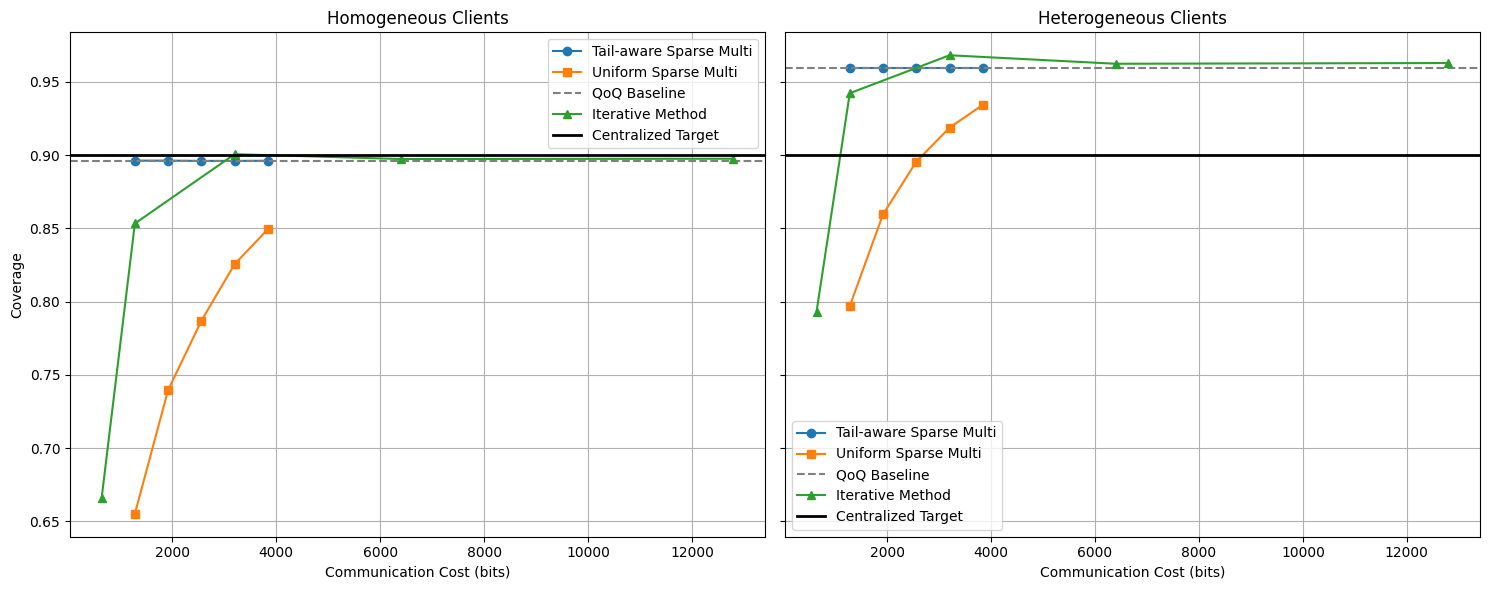

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True)

costs_sparse = [communication_cost(num_clients, k) for k in ks]
costs_iter = [iterative_comm_cost(num_clients, r) for r in rounds_list]
target_coverage = 1 - alpha

# Homogeneous
cover_tail_homo = []
cover_uniform_homo = []
cover_iter_homo = []

for k in ks:
    # Tail-aware
    probs_tail = alpha_adaptive_tail_grid(alpha, k)
    p_t, q_t = sparse_multi_quantile(client_scores_homo, probs_tail)
    q_est_t = estimate_global_threshold(p_t, q_t, alpha)
    cover_tail_homo.append(compute_coverage(y_test, y_test_pred, q_est_t))

    # Uniform
    probs_uni = np.linspace(0, 1, k+2)[1:-1]
    p_u, q_u = sparse_multi_quantile(client_scores_homo, probs_uni)
    q_est_u = estimate_global_threshold(p_u, q_u, alpha)
    cover_uniform_homo.append(compute_coverage(y_test, y_test_pred, q_est_u))

# QoQ
cover_qoq_homo_val = compute_coverage(y_test, y_test_pred, q_qoq_homo)

# Iterative
for r in rounds_list:
    q_iter = iterative_quantile_sync(client_scores_homo, alpha, rounds=r)
    cover_iter_homo.append(compute_coverage(y_test, y_test_pred, q_iter))

ax = axes[0]
ax.plot(costs_sparse, cover_tail_homo, marker='o', label="Tail-aware Sparse Multi")
ax.plot(costs_sparse, cover_uniform_homo, marker='s', label="Uniform Sparse Multi")
ax.axhline(y=cover_qoq_homo_val, linestyle='--', color='gray', label="QoQ Baseline")
ax.plot(costs_iter, cover_iter_homo, marker='^', label="Iterative Method")
ax.axhline(y=target_coverage, color='black', linewidth=2, label="Centralized Target")

ax.set_title("Homogeneous Clients")
ax.set_xlabel("Communication Cost (bits)")
ax.set_ylabel("Coverage")
ax.grid()
ax.legend()

# Heterogeneous
cover_tail = []
cover_uniform = []
cover_iter = []

for k in ks:
    # Tail-aware
    probs_tail = alpha_adaptive_tail_grid(alpha, k)
    p_t, q_t = sparse_multi_quantile(client_scores_hetero, probs_tail)
    q_est_t = estimate_global_threshold(p_t, q_t, alpha)
    cover_tail.append(compute_coverage(y_test, y_test_pred, q_est_t))

    # Uniform
    probs_uni = np.linspace(0, 1, k+2)[1:-1]
    p_u, q_u = sparse_multi_quantile(client_scores_hetero, probs_uni)
    q_est_u = estimate_global_threshold(p_u, q_u, alpha)
    cover_uniform.append(compute_coverage(y_test, y_test_pred, q_est_u))

# QoQ
cover_qoq_val = compute_coverage(y_test, y_test_pred, q_qoq_hetero)

# Iterative
for r in rounds_list:
    q_iter = iterative_quantile_sync(client_scores_hetero, alpha, rounds=r)
    cover_iter.append(compute_coverage(y_test, y_test_pred, q_iter))

ax = axes[1]
ax.plot(costs_sparse, cover_tail, marker='o', label="Tail-aware Sparse Multi")
ax.plot(costs_sparse, cover_uniform, marker='s', label="Uniform Sparse Multi")
ax.axhline(y=cover_qoq_val, linestyle='--', color='gray', label="QoQ Baseline")
ax.plot(costs_iter, cover_iter, marker='^', label="Iterative Method")
ax.axhline(y=target_coverage, color='black', linewidth=2, label="Centralized Target")

ax.set_title("Heterogeneous Clients")
ax.set_xlabel("Communication Cost (bits)")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()


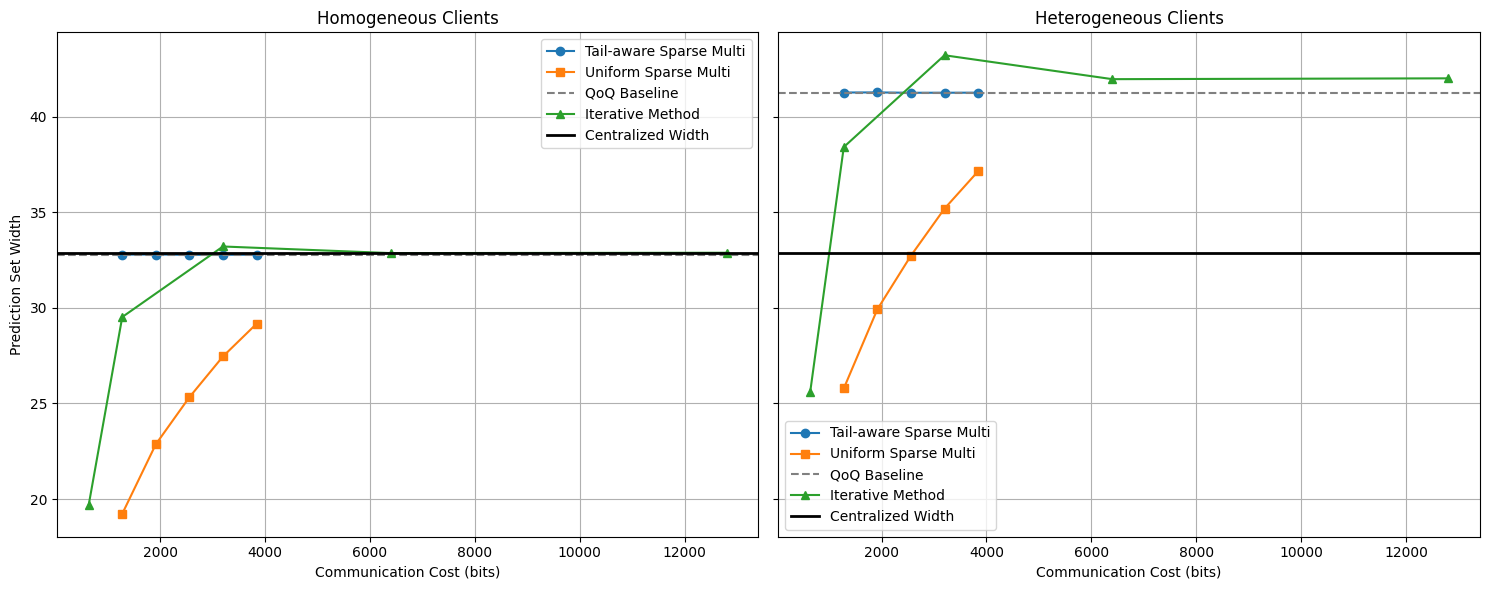

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True)

# Homogeneous
width_tail_homo = []
width_uniform_homo = []
width_iter_homo = []

for k in ks:
    # Tail-aware
    probs_tail = alpha_adaptive_tail_grid(alpha, k)
    p_t, q_t = sparse_multi_quantile(client_scores_homo, probs_tail)
    q_est_t = estimate_global_threshold(p_t, q_t, alpha)
    width_tail_homo.append(2 * q_est_t)

    # Uniform
    probs_uni = np.linspace(0, 1, k+2)[1:-1]
    p_u, q_u = sparse_multi_quantile(client_scores_homo, probs_uni)
    q_est_u = estimate_global_threshold(p_u, q_u, alpha)
    width_uniform_homo.append(2 * q_est_u)

# QoQ
width_qoq_homo_val = 2 * q_qoq_homo

# Iterative
for r in rounds_list:
    q_iter = iterative_quantile_sync(client_scores_homo, alpha, rounds=r)
    width_iter_homo.append(2 * q_iter)

ax = axes[0]
ax.plot(costs_sparse, width_tail_homo, marker='o', label="Tail-aware Sparse Multi")
ax.plot(costs_sparse, width_uniform_homo, marker='s', label="Uniform Sparse Multi")
ax.axhline(y=width_qoq_homo_val, linestyle='--', color='gray', label="QoQ Baseline")
ax.plot(costs_iter, width_iter_homo, marker='^', label="Iterative Method")
ax.axhline(y=2*q_central, color='black', linewidth=2, label="Centralized Width")

ax.set_title("Homogeneous Clients")
ax.set_xlabel("Communication Cost (bits)")
ax.set_ylabel("Prediction Set Width")
ax.grid()
ax.legend()

# Heterogeneous
width_tail = []
width_uniform = []
width_iter = []

for k in ks:
    # Tail-aware
    probs_tail = alpha_adaptive_tail_grid(alpha, k)
    p_t, q_t = sparse_multi_quantile(client_scores_hetero, probs_tail)
    q_est_t = estimate_global_threshold(p_t, q_t, alpha)
    width_tail.append(2 * q_est_t)

    # Uniform
    probs_uni = np.linspace(0, 1, k+2)[1:-1]
    p_u, q_u = sparse_multi_quantile(client_scores_hetero, probs_uni)
    q_est_u = estimate_global_threshold(p_u, q_u, alpha)
    width_uniform.append(2 * q_est_u)

# QoQ
width_qoq_val = 2 * q_qoq_hetero

# Iterative
for r in rounds_list:
    q_iter = iterative_quantile_sync(client_scores_hetero, alpha, rounds=r)
    width_iter.append(2 * q_iter)

ax = axes[1]
ax.plot(costs_sparse, width_tail, marker='o', label="Tail-aware Sparse Multi")
ax.plot(costs_sparse, width_uniform, marker='s', label="Uniform Sparse Multi")
ax.axhline(y=width_qoq_val, linestyle='--', color='gray', label="QoQ Baseline")
ax.plot(costs_iter, width_iter, marker='^', label="Iterative Method")
ax.axhline(y=2*q_central, color='black', linewidth=2, label="Centralized Width")

ax.set_title("Heterogeneous Clients")
ax.set_xlabel("Communication Cost (bits)")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()
